Purpose: Investigate results of maSigPro on parental species.<br>
Author: Anna Pardo<br>
Date initiated: Nov. 10, 2025

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

In [2]:
# set up a function to load the results as a dict of dataframes
def load_dictres(sp,directory):
    # where sp = Ya or Yf, as str
    resd = {}
    for f in os.listdir(directory):
        if f.startswith(sp):
            resd[f] = pd.read_csv(os.path.join(directory,f),sep="\t",header="infer")
    return resd

In [3]:
d = "./"

In [4]:
yares = load_dictres("Ya",d)

In [5]:
yfres = load_dictres("Yf",d)

In [7]:
yares.keys()

dict_keys(['Ya_kmeans_k7_clusters.txt', 'Ya_hclust_k5_clusters.txt', 'Ya_hclust_k7_clusters.txt', 'Ya_kmeans_k5_clusters.txt'])

In [6]:
# function to clean up & merge the results dataframes
def clean_data(resdict):
    dlist = []
    for k,v in resdict.items():
        method = k.strip().split("_")[1]
        kc = k.strip().split("_")[2].lstrip("k")
        v["Cluster_Method"] = method
        v["K"] = kc
        dlist.append(v)
    
    return pd.concat(dlist)

In [7]:
yaclean = clean_data(yares)

In [8]:
yfclean = clean_data(yfres)

In [12]:
yfclean.head()

,cluster,GeneID,Cluster_Method,K
0,5,YufilH1000057m.g,kmeans,7
1,5,YufilH1000069m.g,kmeans,7
2,5,YufilH1000070m.g,kmeans,7
3,5,YufilH1000101m.g,kmeans,7
4,5,YufilH1000134m.g,kmeans,7


In [13]:
yfclean["K"].unique()

array(['7', '5'], dtype=object)

In [27]:
# set up a couple functions to show summaries of counts of genes
def genecount_summary(df,method,k):
    subdf = df[df["Cluster_Method"]==method]
    subdf = subdf[subdf["K"]==k]
    
    return subdf.groupby("cluster").count().reset_index()[["cluster","GeneID"]].rename(columns={"GeneID":method+"_"+k})

In [28]:
def sumdict(df):
    d = {}
    for i in df["Cluster_Method"].unique():
        for j in df["K"].unique():
            d[i+"_"+j] = genecount_summary(df,i,j)
    return d

In [29]:
yasums = sumdict(yaclean)

In [30]:
yfsums = sumdict(yfclean)

In [31]:
yasums

{'kmeans_7':    cluster  kmeans_7
 0        1      3816
 1        2       157
 2        3         8
 3        4       872
 4        5        17
 5        6        44
 6        7         1,
 'kmeans_5':    cluster  kmeans_5
 0        1       303
 1        2         8
 2        3         1
 3        4      4560
 4        5        43,
 'hclust_7':    cluster  hclust_7
 0        1       502
 1        2      1136
 2        3       611
 3        4       464
 4        5       990
 5        6       674
 6        7       538,
 'hclust_5':    cluster  hclust_5
 0        1      1040
 1        2      1136
 2        3      1075
 3        4       990
 4        5       674}

In [33]:
yfsums

{'kmeans_7':    cluster  kmeans_7
 0        1        48
 1        2         8
 2        3       254
 3        4      1187
 4        5      4509
 5        6        13
 6        7         2,
 'kmeans_5':    cluster  kmeans_5
 0        1        65
 1        2      5329
 2        3         2
 3        4       615
 4        5        10,
 'hclust_7':    cluster  hclust_7
 0        1      1500
 1        2      1230
 2        3       920
 3        4       960
 4        5       772
 5        6       400
 6        7       239,
 'hclust_5':    cluster  hclust_5
 0        1      1500
 1        2      1469
 2        3       920
 3        4       960
 4        5      1172}

In [37]:
yasumdf = reduce(lambda x, y: pd.merge(x, y, on = 'cluster',how="left"), list(yasums.values()))

In [38]:
yasumdf

,cluster,kmeans_7,kmeans_5,hclust_7,hclust_5
0,1,3816,303.0,502,1040.0
1,2,157,8.0,1136,1136.0
2,3,8,1.0,611,1075.0
3,4,872,4560.0,464,990.0
4,5,17,43.0,990,674.0
5,6,44,NaN,674,NaN
6,7,1,NaN,538,NaN


In [39]:
yfsumdf = reduce(lambda x, y: pd.merge(x, y, on = 'cluster',how="left"), list(yfsums.values()))

In [40]:
yfsumdf

,cluster,kmeans_7,kmeans_5,hclust_7,hclust_5
0,1,48,65.0,1500,1500.0
1,2,8,5329.0,1230,1469.0
2,3,254,2.0,920,920.0
3,4,1187,615.0,960,960.0
4,5,4509,10.0,772,1172.0
5,6,13,NaN,400,NaN
6,7,2,NaN,239,NaN


In [44]:
yfsumdf["kmeans_5"].sum()

6021.0

## Section 1a: Load & summarize k=6 results (final)

In [28]:
ya6 = pd.read_csv("./Ya_hclust_k6_clusters.txt",sep="\t",header="infer")
ya6.head()

,cluster,GeneID
0,1,Yucal.01G000500.v2.1
1,2,Yucal.01G000900.v2.1
2,3,Yucal.01G001300.v2.1
3,3,Yucal.01G001400.v2.1
4,4,Yucal.01G002500.v2.1


In [29]:
yf6 = pd.read_csv("./Yf_hclust_k6_clusters.txt",sep="\t",header="infer")
yf6.head()

,cluster,GeneID
0,1,YufilH1000057m.g
1,2,YufilH1000069m.g
2,3,YufilH1000070m.g
3,4,YufilH1000101m.g
4,1,YufilH1000134m.g


In [30]:
ya6.groupby("cluster").count().reset_index()

,cluster,GeneID
0,1,1040
1,2,1136
2,3,611
3,4,464
4,5,990
5,6,674


In [31]:
yf6.groupby("cluster").count().reset_index()

,cluster,GeneID
0,1,1500
1,2,1469
2,3,920
3,4,960
4,5,772
5,6,400


## Section 2: CAM genes in parental maSigPro results

In [9]:
# load CAM genes annotations
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp


In [12]:
# subset maSigPro results to just hclust (drop kmeans)
yahc = yaclean[yaclean["Cluster_Method"]=="hclust"]
yfhc = yfclean[yfclean["Cluster_Method"]=="hclust"]

In [15]:
cam.tail()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr
74,YufilH1082501m.g,OG0000793,CAM-light,NADP-dependent malic enzyme,NADP-ME
75,YufilH1086489m.g,OG0000793,CAM-light,NADP-dependent malic enzyme,NADP-ME
76,YufilH1086337m.g,OG0001861,CAM-light,phosphoenolpyruvate carboxykinase,PEPCK
77,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK
78,YufilH1062825m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK


In [14]:
yfhc.head()

,cluster,GeneID,Cluster_Method,K
0,1,YufilH1000057m.g,hclust,5
1,2,YufilH1000069m.g,hclust,5
2,3,YufilH1000070m.g,hclust,5
3,4,YufilH1000101m.g,hclust,5
4,1,YufilH1000134m.g,hclust,5


In [18]:
# function to pull out the CAM genes (and print a summary) in a given species with a given k
def findcam(df,k):
    # where k is a str
    kdf = df[df["K"]==k]
    # subset to CAM genes by merging
    kcam = cam.merge(kdf)
    print(kcam.groupby("cluster").count().reset_index()[["cluster","GeneID"]])
    return kcam

In [19]:
yf5cam = findcam(yfhc,"5")

   cluster  GeneID
0        3       2
1        4       1


In [20]:
yf7cam = findcam(yfhc,"7")

   cluster  GeneID
0        3       2
1        4       1


In [21]:
ya5cam = findcam(yahc,"5")

   cluster  GeneID
0        1       4
1        3       1
2        4       1


In [22]:
ya7cam = findcam(yahc,"7")

   cluster  GeneID
0        3       1
1        5       1
2        7       4


In [23]:
ya5cam

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster,Cluster_Method,K
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,1,hclust,5
1,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,3,hclust,5
2,Yucal.05G198500.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,4,hclust,5
3,Yucal.12G110300.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,1,hclust,5
4,Yucal.12G110500.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,1,hclust,5
5,Yucal.12G110700.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,1,hclust,5


In [24]:
ya7cam

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster,Cluster_Method,K
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,7,hclust,7
1,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,3,hclust,7
2,Yucal.05G198500.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,5,hclust,7
3,Yucal.12G110300.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,7,hclust,7
4,Yucal.12G110500.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,7,hclust,7
5,Yucal.12G110700.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,7,hclust,7


In [25]:
yf5cam

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster,Cluster_Method,K
0,YufilH1042055m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,3,hclust,5
1,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,4,hclust,5
2,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,3,hclust,5


In [26]:
yf7cam

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster,Cluster_Method,K
0,YufilH1042055m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,3,hclust,7
1,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,4,hclust,7
2,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,3,hclust,7


## Section 2a: CAM genes in k=6 results

In [32]:
cam6a = cam.merge(ya6)
cam6a.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,1
1,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,3
2,Yucal.05G198500.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,5
3,Yucal.12G110300.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,1
4,Yucal.12G110500.v2.1,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,1


In [33]:
cam6f = cam.merge(yf6)
cam6f.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster
0,YufilH1042055m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,3
1,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,4
2,YufilH1062820m.g,OG0002410,CAM-light,"pyruvate, phosphate dikinase",PPDK,3


## Section 3: Plot cluster expression profiles (k=6 data only - final)

In [35]:
# load parental TPM
yatpm = pd.read_csv("../../rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",sep="\t",header="infer")
yftpm = pd.read_csv("../../rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",sep="\t",header="infer")

In [38]:
c6 = yf6[yf6["cluster"]==6]

In [39]:
c6.head()

,cluster,GeneID
13,6,YufilH1000245m.g
14,6,YufilH1000254m.g
53,6,YufilH1000812m.g
75,6,YufilH1001099m.g
85,6,YufilH1001263m.g


In [40]:
# for code development: plot smallest cluster first (Yf cluster 6)
## subset data
cols = ["sample_name","genotype","treat","ZT"]+list(c6["GeneID"].unique())


In [42]:
fc6 = yftpm[cols]
fc6.head()

,sample_name,genotype,treat,ZT,YufilH1000245m.g,YufilH1000254m.g,YufilH1000812m.g,YufilH1001099m.g,YufilH1001263m.g,YufilH1001320m.g,...,YufilH1094276m.g,YufilH1094298m.g,YufilH1094511m.g,YufilH1094574m.g,YufilH1094609m.g,YufilH1094671m.g,YufilH1094826m.g,YufilH1094979m.g,YufilH1094995m.g,YufilH1095126m.g
0,X73,2.0,D,13.0,0.461779,4.576511,44.671243,19.126905,89.663140,39.248424,...,36.300061,0.361563,5.544339,21.560570,20.281599,0.546630,4.100700,0.553977,25.300611,2.102850
1,X74,2.0,D,17.0,1.204948,3.618715,83.739652,17.482701,97.912981,62.068608,...,23.274705,0.142947,4.641872,22.152213,12.663432,2.161142,2.815841,0.547547,29.231431,2.554231
2,X64,2.0,W,5.0,0.486662,3.215409,192.295348,19.972612,24.355478,107.795257,...,34.357777,0.889107,2.978831,14.774200,10.664634,1.728255,1.364736,0.000000,22.032966,1.869051
3,X101,27.0,D,9.0,1.770397,1.322284,136.917130,20.989829,71.392161,101.083239,...,26.535909,1.386183,4.751388,14.286945,27.025825,1.816276,1.654895,0.495569,34.572232,2.408896
4,X102,27.0,D,1.0,0.877422,2.100429,130.078788,11.947559,39.935469,49.459276,...,5.856974,0.381668,1.377089,10.677266,11.202566,0.000000,2.563057,0.146195,13.483368,1.323844


In [43]:
len(fc6.columns)

404

In [44]:
plot = fc6.set_index(["sample_name","genotype","treat"])

In [45]:
plot.head()

,,,ZT,YufilH1000245m.g,YufilH1000254m.g,YufilH1000812m.g,YufilH1001099m.g,YufilH1001263m.g,YufilH1001320m.g,YufilH1001442m.g,YufilH1001642m.g,YufilH1001677m.g,...,YufilH1094276m.g,YufilH1094298m.g,YufilH1094511m.g,YufilH1094574m.g,YufilH1094609m.g,YufilH1094671m.g,YufilH1094826m.g,YufilH1094979m.g,YufilH1094995m.g,YufilH1095126m.g
sample_name,genotype,treat,,,,,,,,,,,,,,,,,,,,,
X73,2.0,D,13.0,0.461779,4.576511,44.671243,19.126905,89.663140,39.248424,27.723715,11.997227,16.533106,...,36.300061,0.361563,5.544339,21.560570,20.281599,0.546630,4.100700,0.553977,25.300611,2.102850
X74,2.0,D,17.0,1.204948,3.618715,83.739652,17.482701,97.912981,62.068608,16.500515,13.296488,13.281985,...,23.274705,0.142947,4.641872,22.152213,12.663432,2.161142,2.815841,0.547547,29.231431,2.554231
X64,2.0,W,5.0,0.486662,3.215409,192.295348,19.972612,24.355478,107.795257,19.267434,6.909119,12.662777,...,34.357777,0.889107,2.978831,14.774200,10.664634,1.728255,1.364736,0.000000,22.032966,1.869051
X101,27.0,D,9.0,1.770397,1.322284,136.917130,20.989829,71.392161,101.083239,17.395039,6.685710,20.710874,...,26.535909,1.386183,4.751388,14.286945,27.025825,1.816276,1.654895,0.495569,34.572232,2.408896
X102,27.0,D,1.0,0.877422,2.100429,130.078788,11.947559,39.935469,49.459276,6.074923,6.747388,3.500631,...,5.856974,0.381668,1.377089,10.677266,11.202566,0.000000,2.563057,0.146195,13.483368,1.323844


In [46]:
c = list(plot.columns)

In [47]:
c.remove("ZT")

In [52]:
# reformat plot into a long format (one column with individual TPM of all genes)
longfc6 = pd.melt(fc6,id_vars=["sample_name","genotype","treat","ZT"],value_vars=c).rename(columns={"variable":"GeneID","value":"TPM"})


In [53]:
longfc6.head()

,sample_name,genotype,treat,ZT,GeneID,TPM
0,X73,2.0,D,13.0,YufilH1000245m.g,0.461779
1,X74,2.0,D,17.0,YufilH1000245m.g,1.204948
2,X64,2.0,W,5.0,YufilH1000245m.g,0.486662
3,X101,27.0,D,9.0,YufilH1000245m.g,1.770397
4,X102,27.0,D,1.0,YufilH1000245m.g,0.877422


<AxesSubplot: xlabel='ZT', ylabel='TPM'>

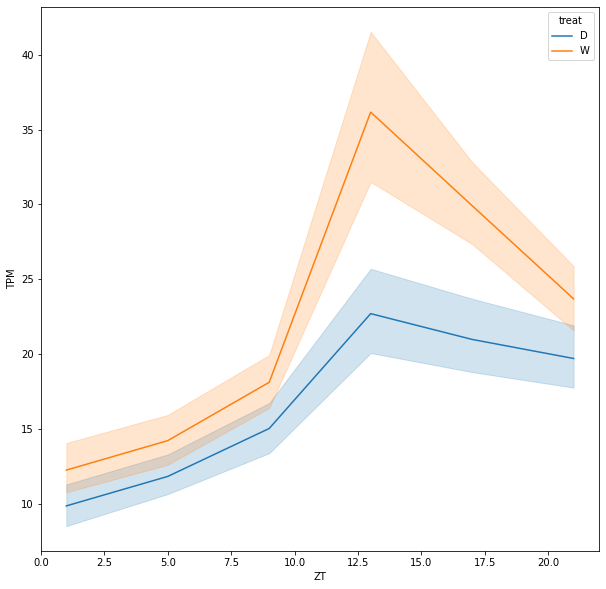

In [57]:
fig,ax = plt.subplots(figsize=(10,10))
sns.lineplot(data=longfc6,x="ZT",y="TPM",hue="treat")
# this is mostly notes for later:
ax[0].fill_between(x,0,1.01*max(p2ya["PPC2_1"]),where=x>=xthresh,color="gray",alpha=0.3)
ax[0].set_ylim(0,1.00001*max(p2ya["PPC2_1"]))
ax[0].set_xlim(0,24)
ax[0].tick_params(axis="both",which="major",labelsize=16)
ax[0].set_xticks(ticks=list(p2ya["ZT"].unique()))
ax[0].set_xlabel("")
ax[0].set_ylabel("TPM from uniquely mapped reads",fontsize=20)
ax[0].set_title("PPC2_1",fontsize=20)

In [96]:
# set up a function to set up plotting data for a given species & cluster
def cplotdata(cdf,cnum,tpm):
    subdf = cdf[cdf["cluster"]==cnum]
    cols = ["sample_name","genotype","treat","ZT"]+list(subdf["GeneID"].unique())
    ctpm = tpm[cols]
    cols.remove("sample_name")
    cols.remove("genotype")
    cols.remove("treat")
    cols.remove("ZT")
    long = pd.melt(ctpm,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cols).rename(columns={"variable":"GeneID","value":"TPM"})
    return long.sort_values(by="treat",ascending=False)


In [107]:
# set up a function to plot all clusters for each species
def clustplot(cdf,tpm,sp):
    fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(15,25))
    r = 0
    c = 0
    
    t = np.arange(0,25)
    xthresh = 12
    
    for i in cdf["cluster"].unique():
        plot = cplotdata(cdf,i,tpm)
        x = sns.lineplot(ax=ax[r,c],data=plot,x="ZT",y="TPM",hue="treat")
        ax[r,c].fill_between(t,0,150,where=t>=xthresh,color="gray",alpha=0.3)
        ax[r,c].set_ylim(0,145)
        ax[r,c].set_xlim(0,24)
        ax[r,c].tick_params(axis="both",which="major",labelsize=16)
        ax[r,c].set_xticks(ticks=list(plot["ZT"].unique()))
        ax[r,c].set_xlabel("")
        ax[r,c].set_ylabel("TPM from uniquely mapped reads",fontsize=20)
        ax[r,c].set_title("Cluster "+str(i),fontsize=20)
        
        if (r==0 and c==0):
            r=0
            c = 1
        elif (r==0 and c==1):
            r=1
            c=0
        elif (r==1 and c==0):
            r=1
            c=1
        elif (r==1 and c==1):
            r=2
            c=0
        elif (r==2 and c==0):
            r=2
            c=1
            
    plt.savefig("cluster_profiles_"+sp+".png",dpi=200,bbox_inches="tight")
    plt.savefig("cluster_profiles_"+sp+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig("cluster_profiles_"+sp+".svg",dpi=200,bbox_inches="tight")

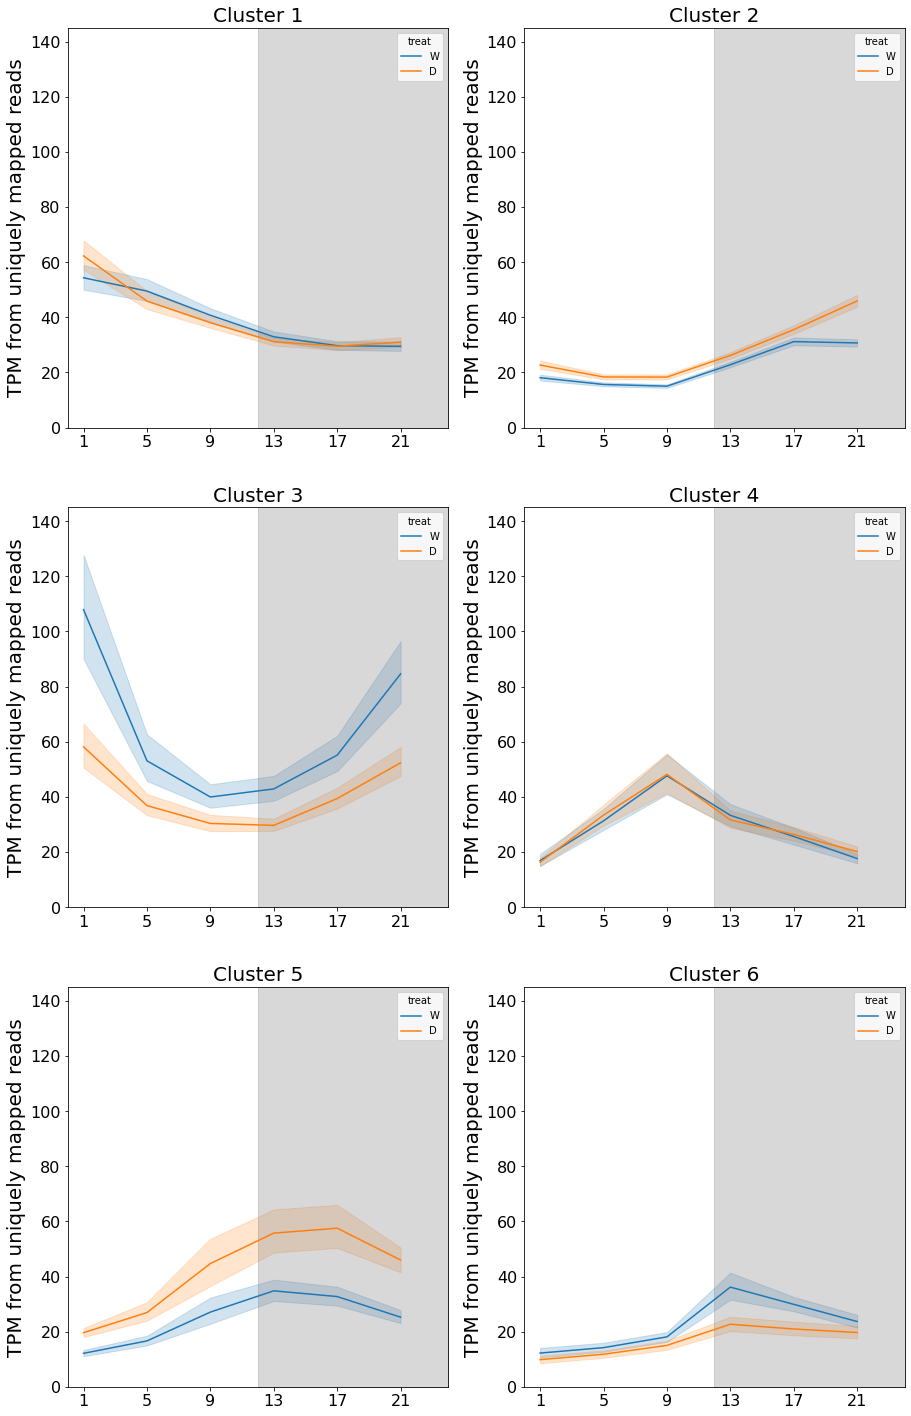

In [108]:
clustplot(yf6,yftpm,"Yf")

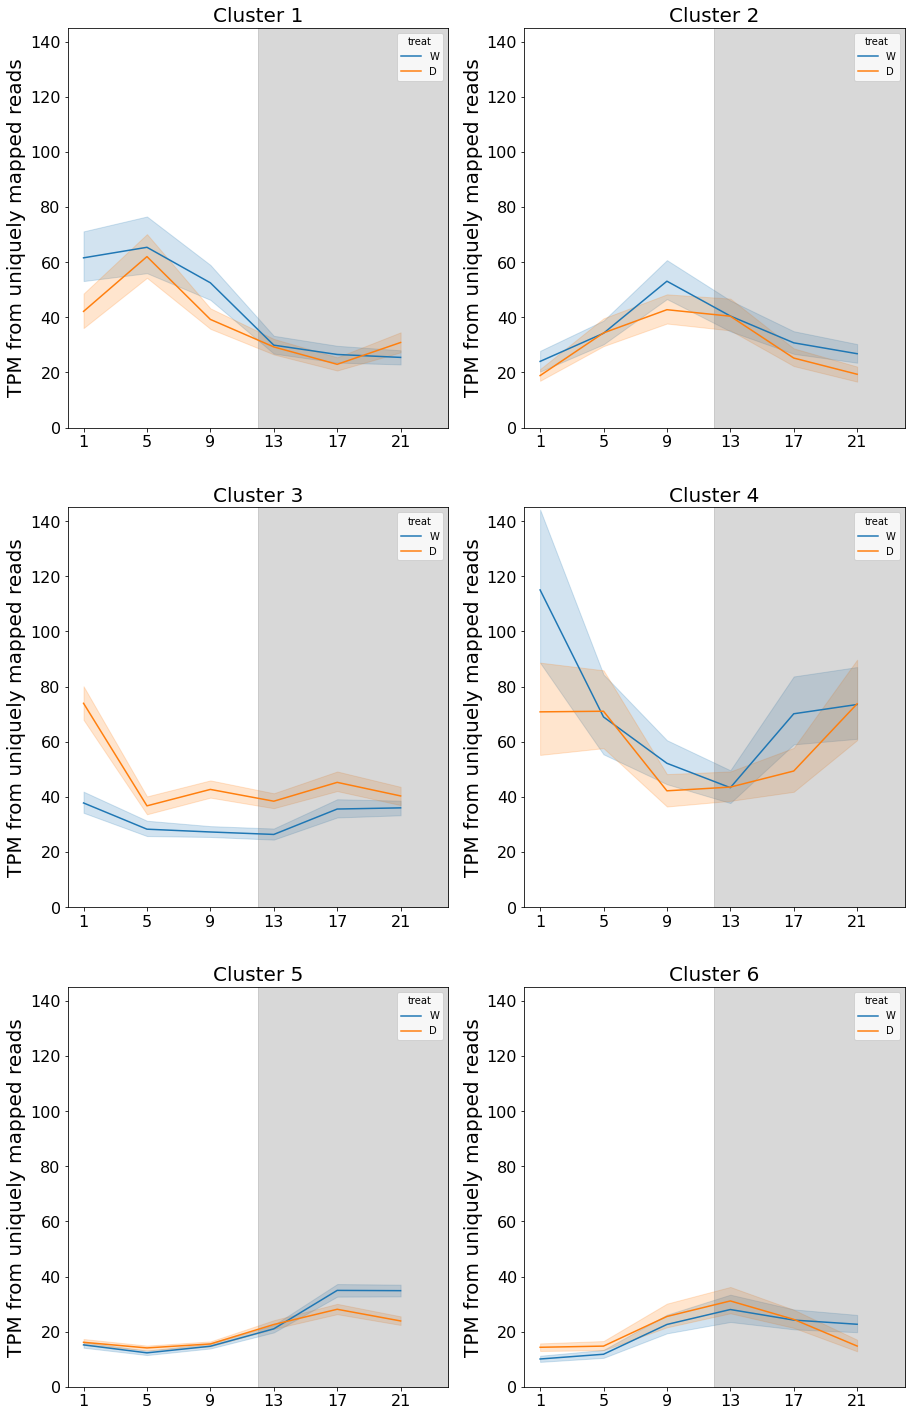

In [109]:
clustplot(ya6,yatpm,"Ya")